### **Comparing discharges of caravan vs diag_dset**

In [1]:
# Imports
from datetime import datetime
import os
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import glob 
import numpy as np
import netCDF4 as nc
from scipy.spatial import KDTree
from mpl_toolkits.basemap import Basemap
import cartopy.crs as ccrs
import math
from scipy import stats
import matplotlib.colors as mcolors
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import geopy.distance
import random
from datetime import date, timedelta

#### Load dsets

In [2]:
# diagnostics
dset_version = 'v7'
dir_dset = '/obs/ecastonguay/scripts/diag_dset_' + dset_version + '.nc'
diag_dset = xr.open_dataset(dir_dset, engine="netcdf4") # discharge dataset

# caravan
dir_dset = '/obs/ecastonguay/scripts/WB_q_estimate_v2.nc'
carvn_dset = xr.open_dataset(dir_dset, engine="netcdf4") # discharge dataset
# (change gauge ids to actual int)
carvn_dset["gauge_id"] = carvn_dset["gauge_id"].astype(str)
carvn_dset["gauge_id"] = carvn_dset["gauge_id"].str.replace("GRDC_", "").astype(int)
carvn_dset = carvn_dset.assign_coords(gauge=carvn_dset.gauge_id.values)
# (resample)
carvn_dset = carvn_dset.resample(time='MS').mean(skipna=True)
print(carvn_dset)

#print(carvn_dset['run_gpm_gleam_itsg'].time)
#df = carvn_dset['run_gpm_gleam_itsg'].groupby('time.month')#.mean('time') # 5302310
#df = df.sel(gauge=5302310).to_dataframe()
#print(df)

<xarray.Dataset> Size: 3MB
Dimensions:             (time: 36, gauge: 3788)
Coordinates:
  * time                (time) datetime64[ns] 288B 2023-01-01 ... 2025-12-01
  * gauge               (gauge) int64 30kB 1159100 1159103 ... 6870630 6870640
Data variables:
    gauge_id            (time, gauge) int64 1MB 1159100 1159103 ... 6870640
    run_gpm_gleam_itsg  (time, gauge) float32 545kB 4.205e+03 4.039e+03 ... nan
    run_era_itsg        (time, gauge) float32 545kB 3.795e+03 3.713e+03 ... nan
    run_gpm_gleam_csr   (time, gauge) float32 545kB -1.371e+03 ... nan
    run_era_csr         (time, gauge) float32 545kB -1.781e+03 ... 33.24


#### Common stations

In [8]:
# eve ids
co = 6 # number of correspondences
mask_coincide = (diag_dset.dschg_global_g.notnull() & diag_dset.dschg_global_s.notnull()) # Array of True/False. True where there are both swot & grdc data. .notnull() is pandas but works with np.nan
n_coincide = mask_coincide.sum(dim="time") # sum of Trues per station (5241,) # [tested]
ids_diag = n_coincide.id.where(n_coincide >= co, drop=True).values.flat
# victor ids
ids_carvn = carvn_dset.gauge_id.values.flat

# values that intersect
ints = set(ids_diag).intersection(ids_carvn)
print(ints)

# open csv with attributes
dir = '/obs/ecastonguay/scripts/attributes_other_grdc.csv'
atr_csv = pd.read_csv(dir)
atr_csv["gauge_id"] = atr_csv["gauge_id"].str.extract(r"GRDC_(\d+)").astype(int)
#print(atr_csv)

# compare lon, lat for one station
station = 5202057
x_d = diag_dset.sel(id=station)['geox_global_g'].item()
y_d = diag_dset.sel(id=station)['geoy_global_g'].item()
#print("grdc no:",station,y_d, x_d) # then compare with values in csv


{np.int64(4208640), np.int64(4208645), np.int64(4147210), np.int64(4122636), np.int64(4122637), np.int64(4122638), np.int64(4122650), np.int64(4231200), np.int64(4132900), np.int64(4235300), np.int64(4235301), np.int64(3625000), np.int64(6854700), np.int64(6854701), np.int64(6854703), np.int64(6854707), np.int64(4149300), np.int64(6854710), np.int64(6243030), np.int64(4122700), np.int64(4122701), np.int64(3649614), np.int64(5607500), np.int64(3649617), np.int64(3649618), np.int64(3649619), np.int64(4126801), np.int64(4126802), np.int64(4126803), np.int64(4126804), np.int64(4126805), np.int64(4231250), np.int64(4126810), np.int64(4208730), np.int64(3651678), np.int64(4208734), np.int64(3651680), np.int64(4149350), np.int64(4147320), np.int64(5202044), np.int64(4147330), np.int64(4126851), np.int64(1159300), np.int64(3637380), np.int64(1159302), np.int64(5204101), np.int64(5204102), np.int64(1159305), np.int64(5204104), np.int64(5204106), np.int64(4147340), np.int64(6731910), np.int64(68

#### Compare discharges

List of stations to plot is: [np.int64(1159100), np.int64(1159300), np.int64(1159302), np.int64(1159305), np.int64(1159490), np.int64(1159535), np.int64(1159545), np.int64(1159550), np.int64(1159651), np.int64(1159675)]


<Figure size 1200x600 with 0 Axes>

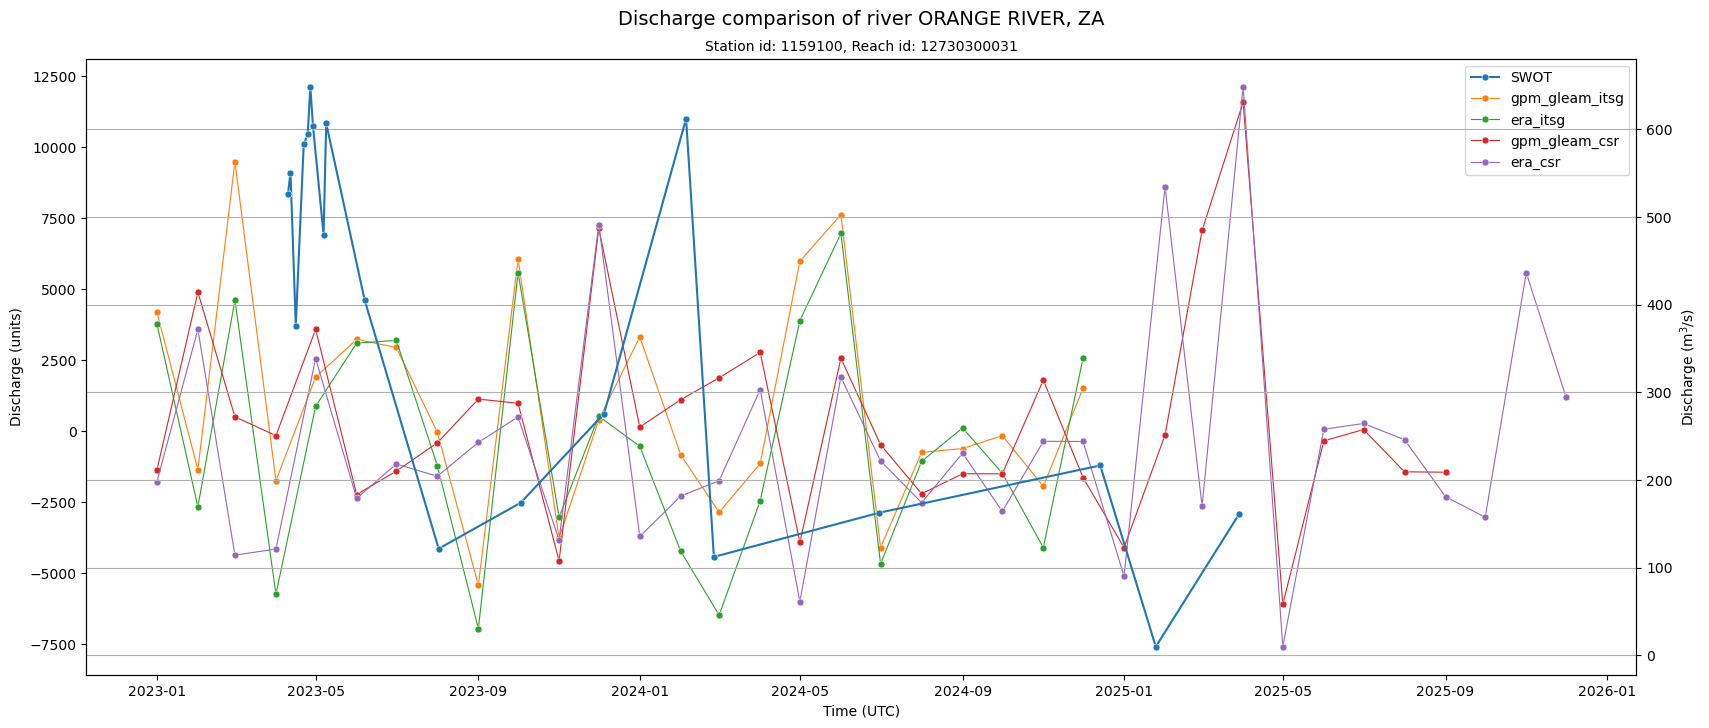

<Figure size 1200x600 with 0 Axes>

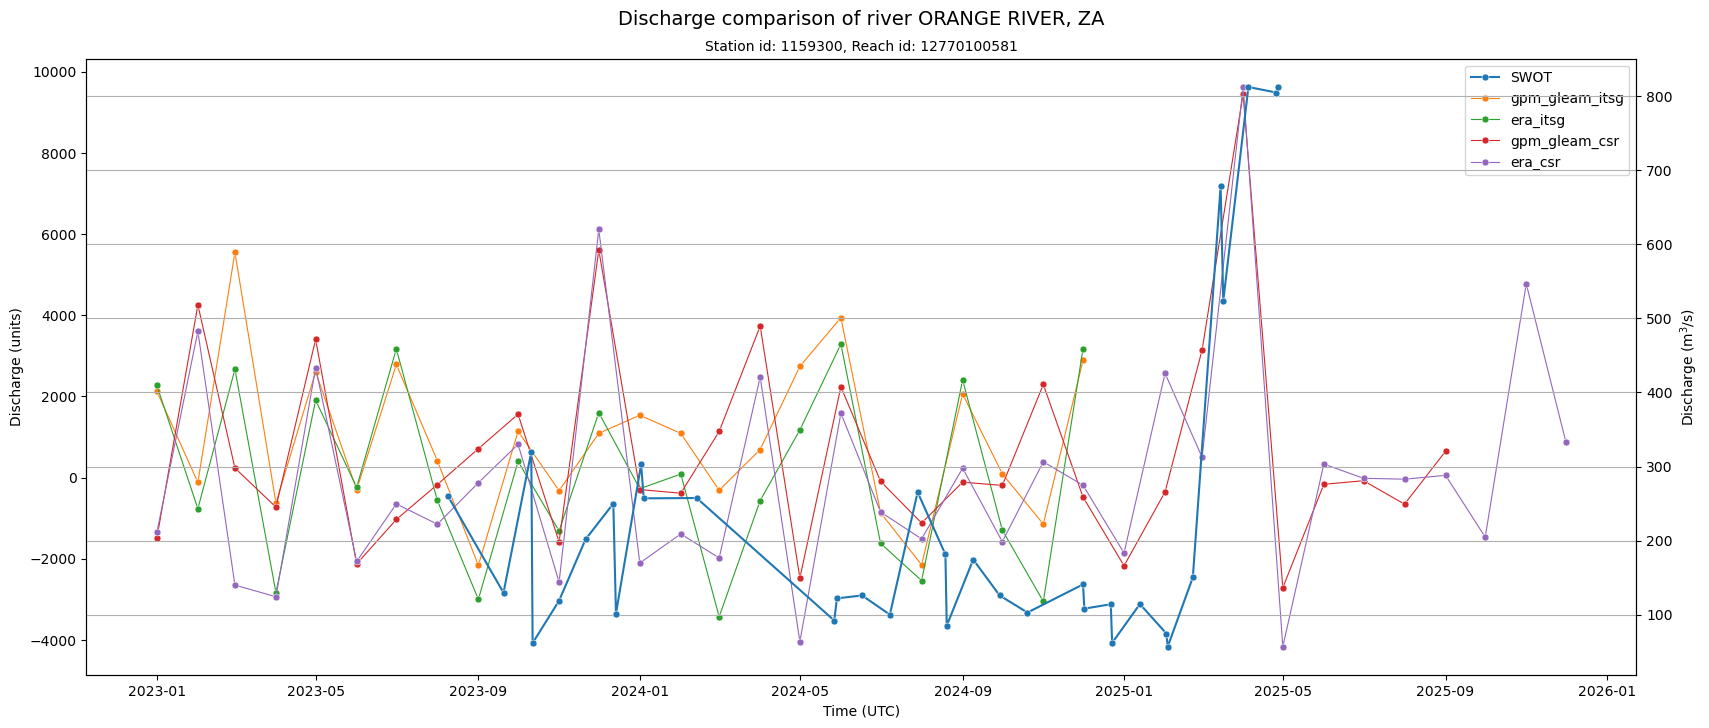

<Figure size 1200x600 with 0 Axes>

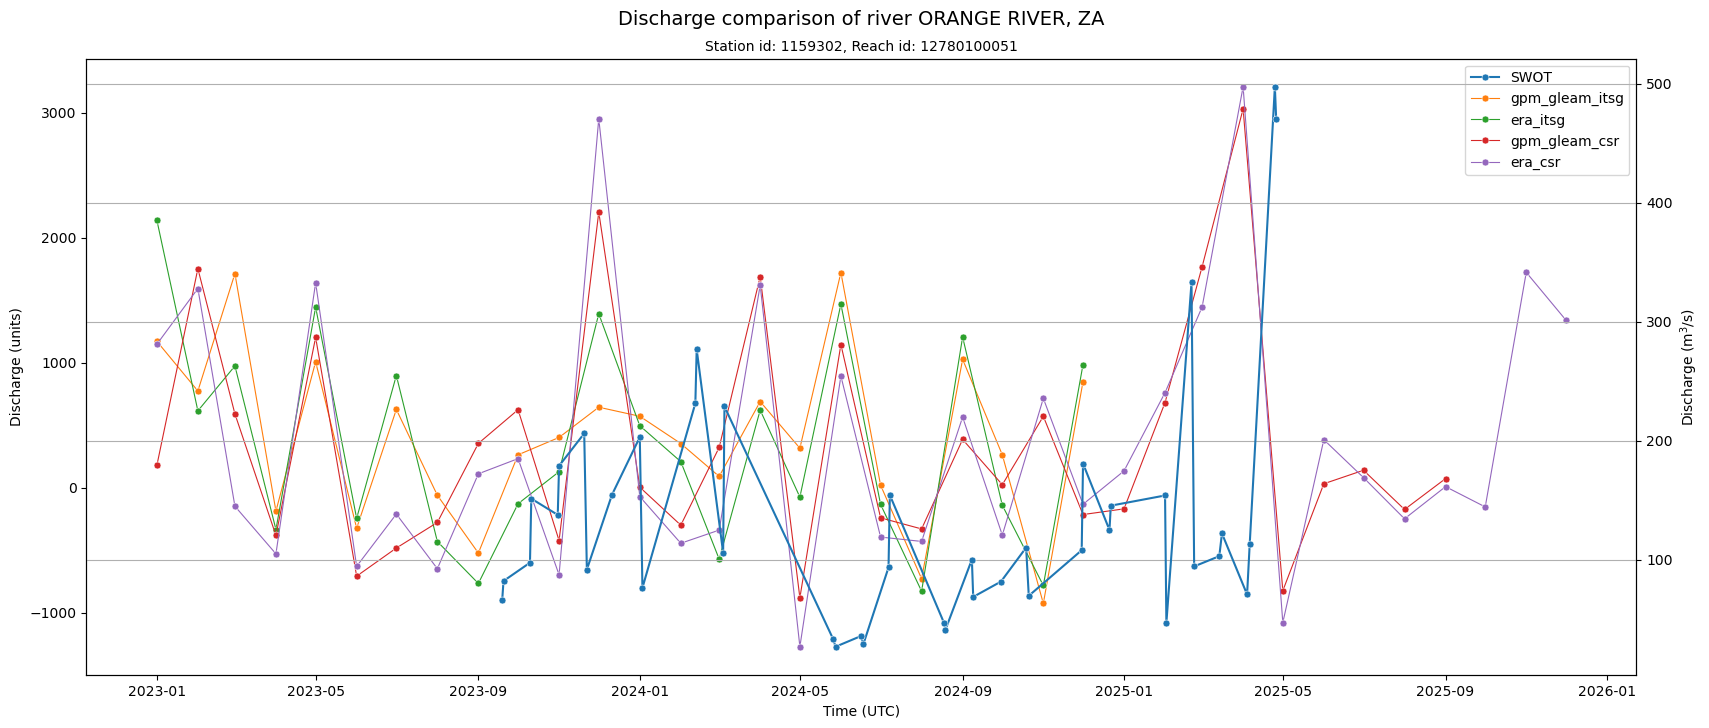

<Figure size 1200x600 with 0 Axes>

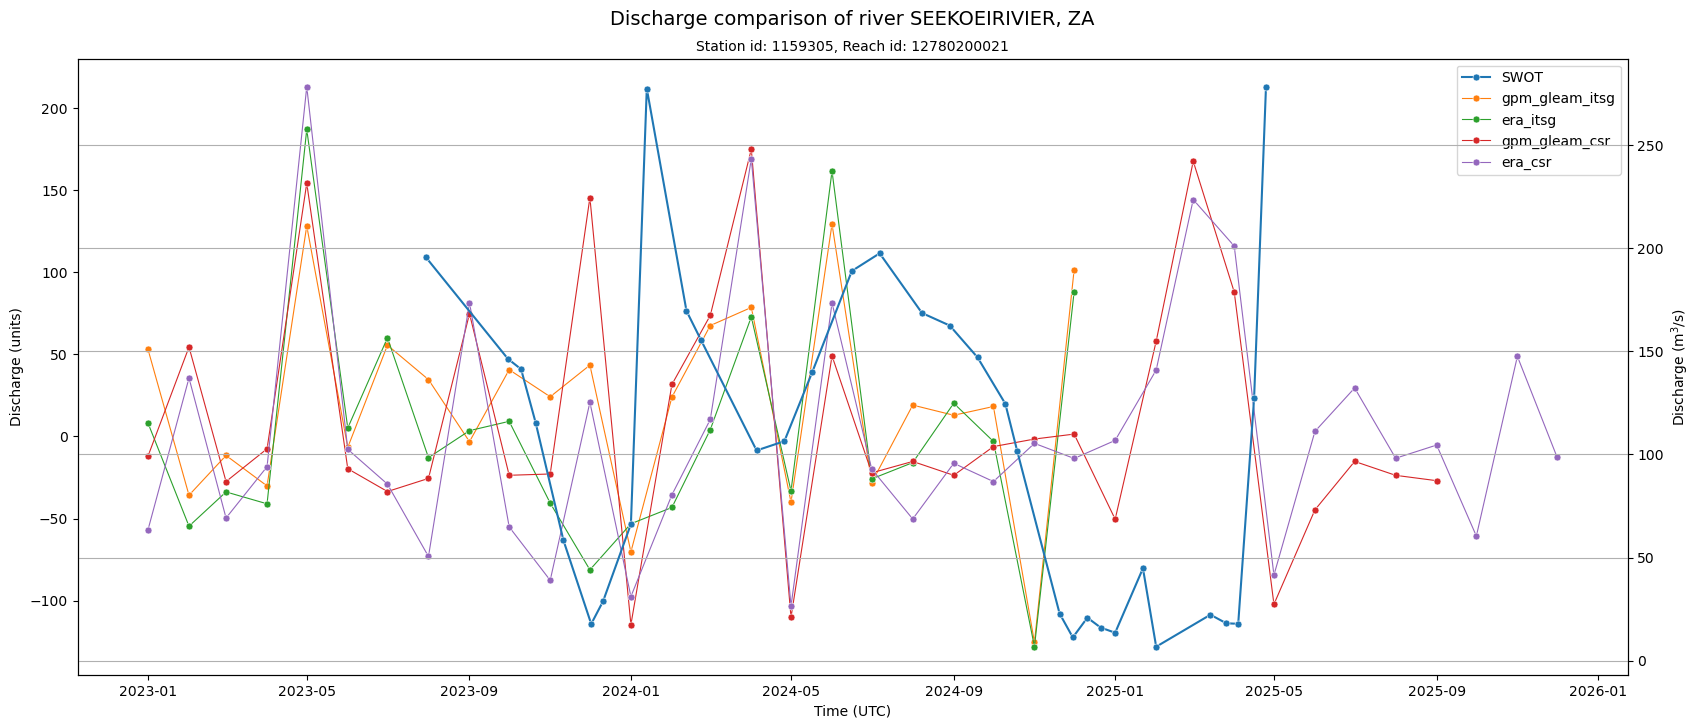

<Figure size 1200x600 with 0 Axes>

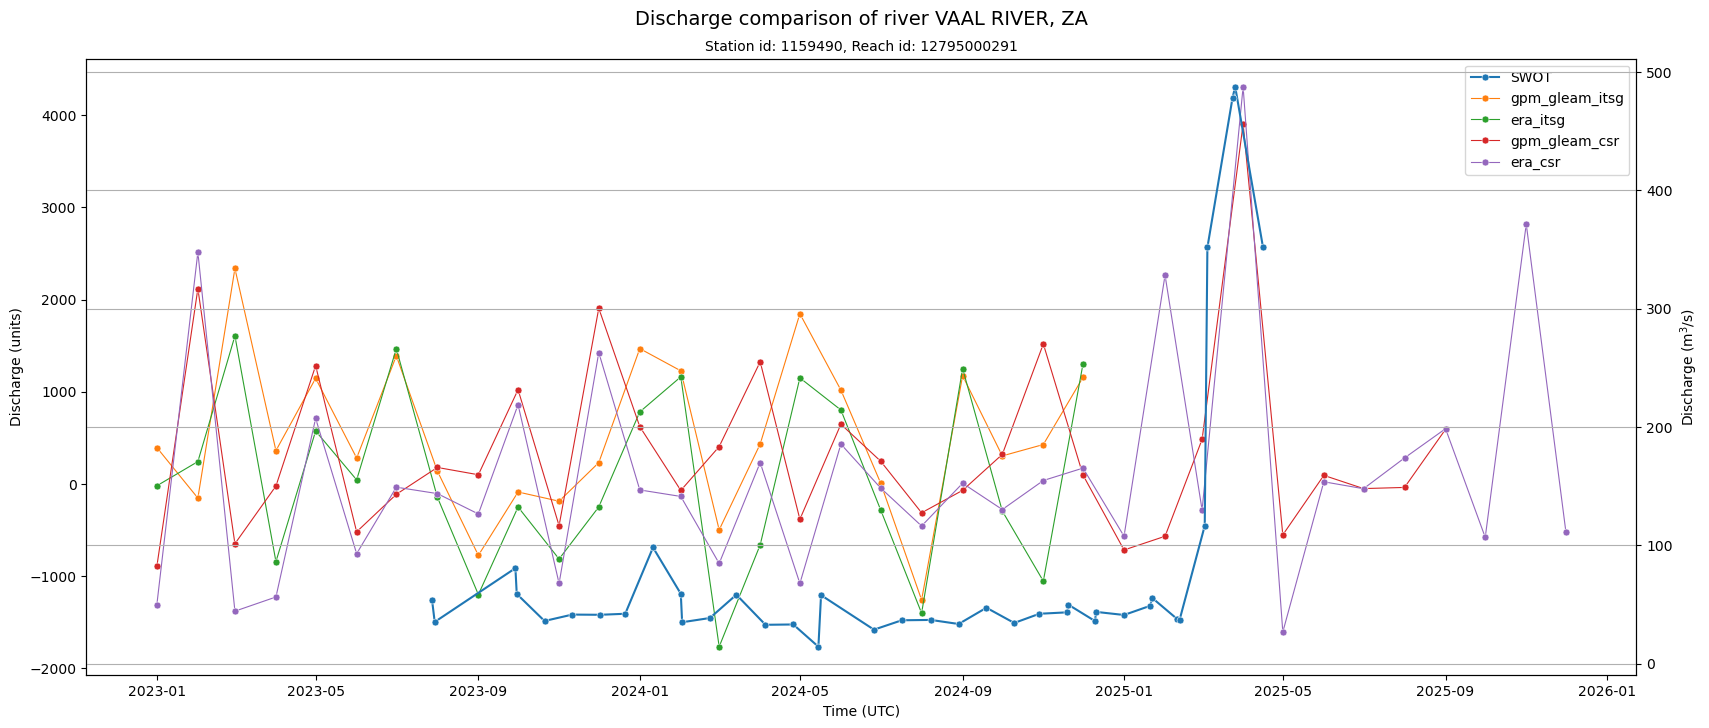

<Figure size 1200x600 with 0 Axes>

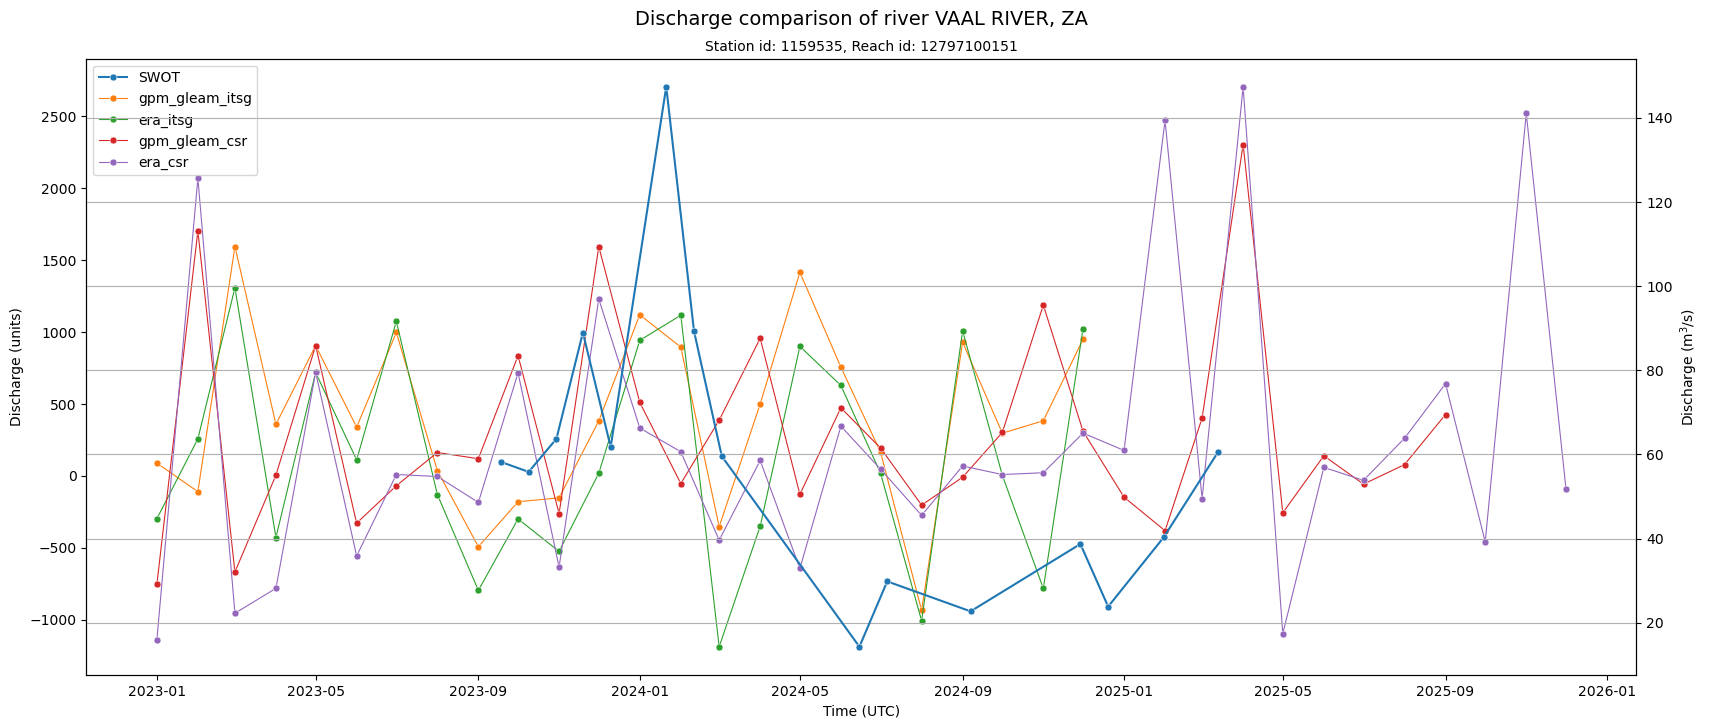

<Figure size 1200x600 with 0 Axes>

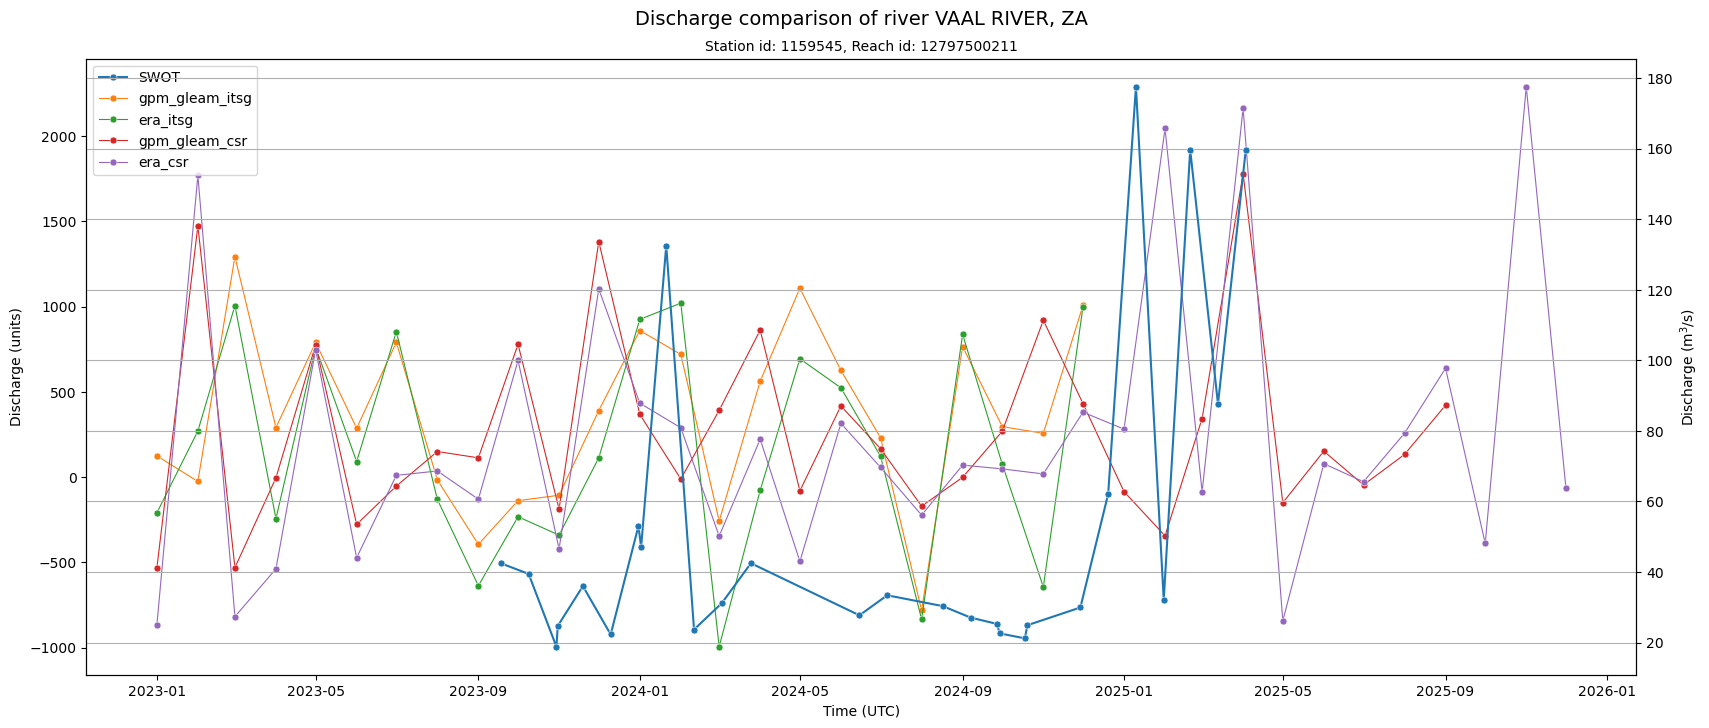

<Figure size 1200x600 with 0 Axes>

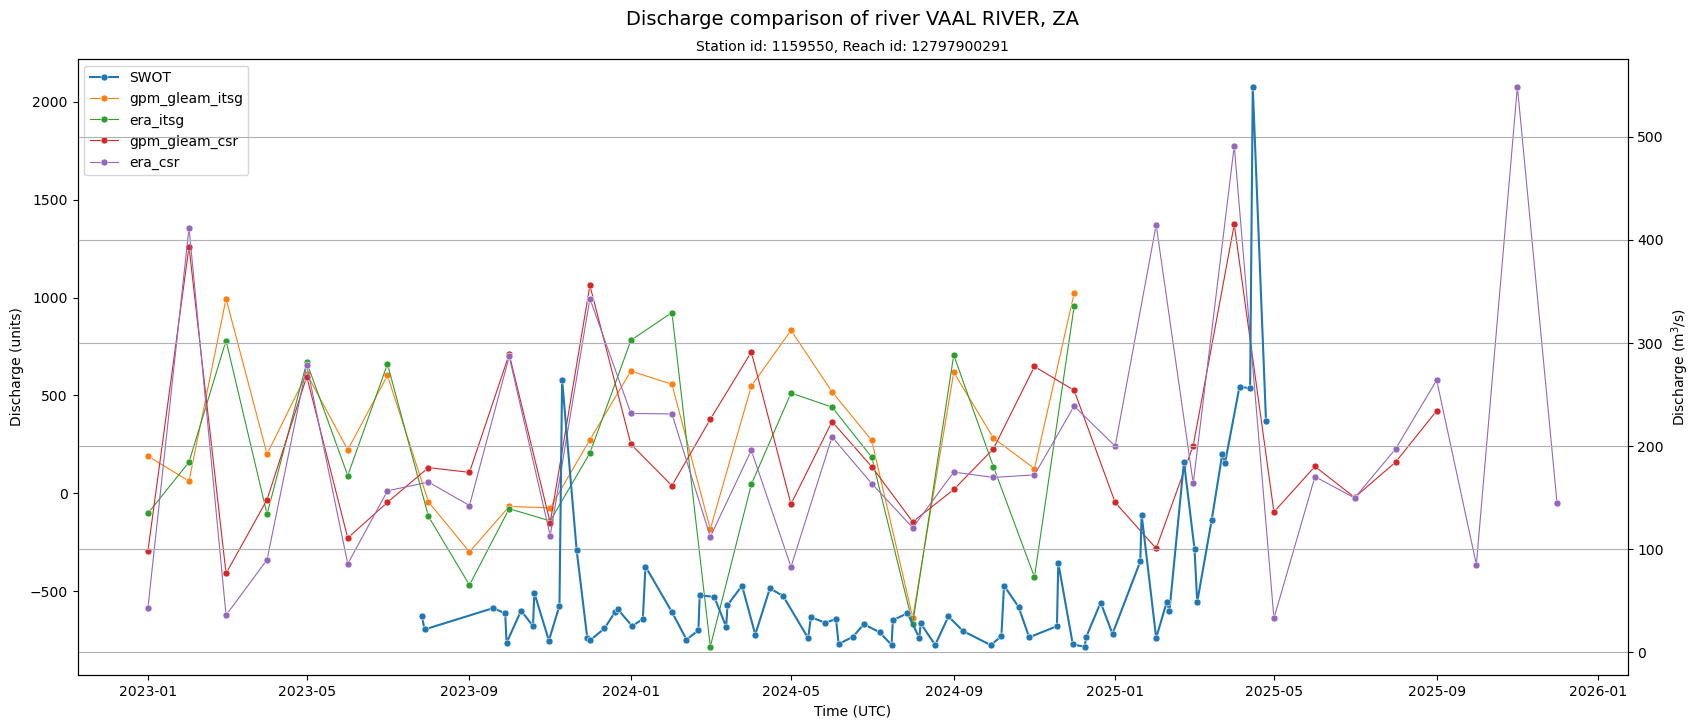

<Figure size 1200x600 with 0 Axes>

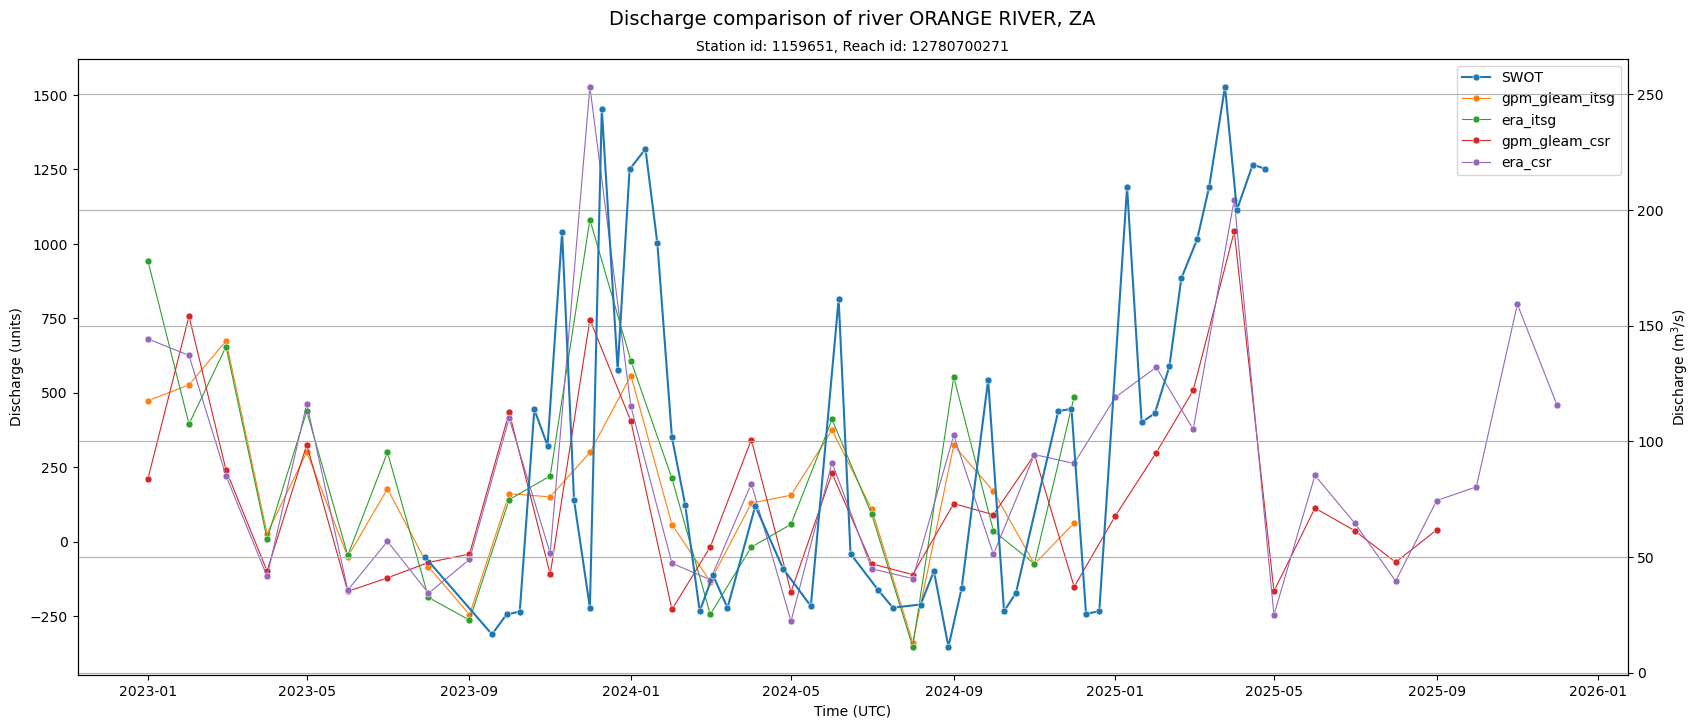

<Figure size 1200x600 with 0 Axes>

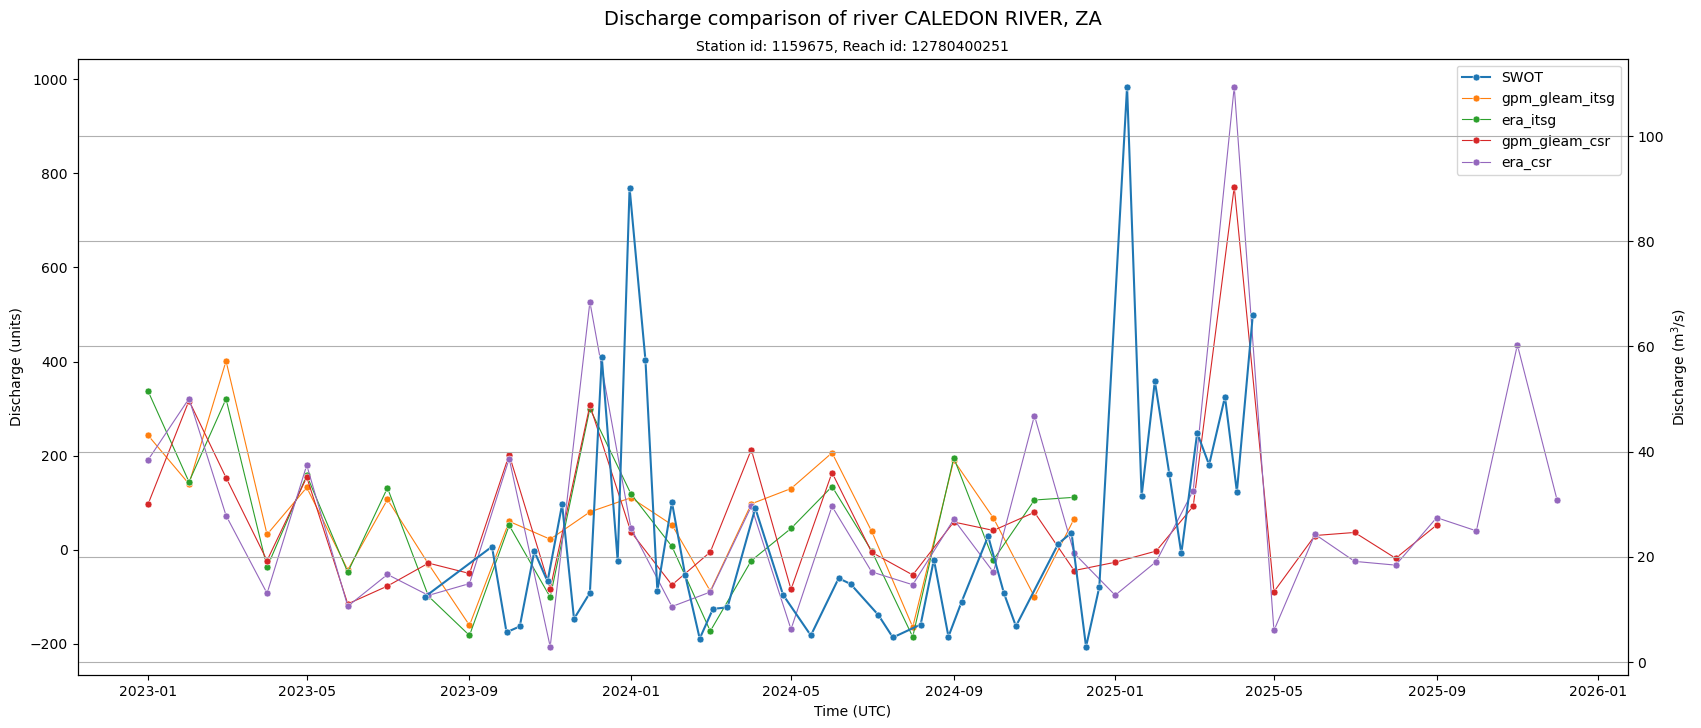

In [11]:
list_stations_plot = sorted(ints)[:10] # subset of all the corresponding stations
print(f"List of stations to plot is: {list_stations_plot}")
use_target_date_filter = False # SELECT True if we want to use the above specified target dates, False if the goal is to display the discharge data for all time period available
save = False # change graph title
save_path = '/obs/ecastonguay/scripts/figures/'

# Making the plots          
for station_id in list_stations_plot:        
    # 1) eve
    q_eve = diag_dset.sel(id=station_id) #['dschg_global_s']      
    # reach id
    closest_reach_id = q_eve['id_global_s'].values
    if ~np.isnan(closest_reach_id):
        closest_reach_id = closest_reach_id.astype(int) 
    
    # 2) victor
    # area = atr_csv.loc[atr_csv["gauge_id"] == station_id, "area"].iloc[0] # not necessary since victor produced v2
    q_vic = carvn_dset.sel(gauge=station_id)
    q_1 = q_vic['run_gpm_gleam_itsg'] #.values *area) / (24*3600) *10^9
    q_2 = q_vic['run_era_itsg'] #*area) / (24*3600*10^9) *10^9
    q_3 = q_vic['run_gpm_gleam_csr'] #*area) / (24*3600) *10^9
    q_4 = q_vic['run_era_csr'] #*area) / (24*3600) *10^9

    # get river name and country
    river_name = q_eve['river_global_g'].values
    river_country = q_eve['country_global_g'].values
        
    # plot
    plt.figure(figsize=(12, 6))
    fig, ax1 = plt.subplots(1,1, figsize=(20, 8))
    
    ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axiscolor = 'tab:blue'ax2.set_ylabel('sin', color=color)  # we already handled the x-label with ax1ax2.plot(t, data2, color=color)ax2.tick_params(axis='y', labelcolor=color)
    plt.title(f"Station id: {station_id}, Reach id: {closest_reach_id}", fontsize=10) 
    plt.gca().text(0.5, 1.055, f"Discharge comparison of river {river_name}, {river_country}", transform=plt.gca().transAxes, ha="center", fontsize=14)
    ax1.set_xlabel('Time (UTC)') 
    ax2.set_ylabel(r'Discharge (m$^3$/s)')
    ax1.set_ylabel(r'Discharge (units)')
    plt.grid(True)

    # filtering nans out of the swot data so that each dot in the graph is connected to another (the "orange problem")
    dschg_swt = q_eve['dschg_global_s']
    or_mask = ~np.isnan(dschg_swt.values)

    ax2.plot(q_eve['time'].values[or_mask],dschg_swt.values[or_mask], marker='o', color='tab:blue', markersize=5, label='SWOT', markeredgecolor='white', markeredgewidth=0.4, linestyle='-')
    ax1.plot(q_1.time.values, q_1.values, marker='o', color='tab:orange', markersize=5, linewidth = 0.8, label='gpm_gleam_itsg', alpha=1, markeredgecolor='white', markeredgewidth=0.4)
    ax1.plot(q_2.time.values, q_2.values, marker='o', color='tab:green', markersize=5, linewidth = 0.8, label='era_itsg', alpha=1, markeredgecolor='white', markeredgewidth=0.4)
    ax1.plot(q_3.time.values, q_3.values, marker='o', color='tab:red', markersize=5, linewidth = 0.8, label='gpm_gleam_csr', alpha=1, markeredgecolor='white', markeredgewidth=0.4)
    ax1.plot(q_4.time.values, q_4.values, marker='o', color='tab:purple', markersize=5, linewidth = 0.8, label='era_csr', alpha=1, markeredgecolor='white', markeredgewidth=0.4)
    
    # legend
    handles1, labels1 = ax2.get_legend_handles_labels()
    handles2, labels2 = ax1.get_legend_handles_labels()
    ax1.legend(handles1 + handles2, labels1 + labels2)

    fig_name = f'caravan_comp_monthly_v2_s{station_id}.png' 

if save:
    plt.savefig(save_path +f'{fig_name}', dpi=400, bbox_inches='tight')
    print(f"Saved") # *** currently no error message if one of the station required to be plotted isn't in the GRDC data -> print(f"There is no correspondence in the GRDC in situ files for station id {station_id}")

#plt.ylim(0,None)
plt.show()  
